#Importando as bibliotecas necessárias

In [85]:
import os
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Embedding, Input, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve, auc
from imblearn.under_sampling import RandomUnderSampler


#Importando o df
Setando o tamanho do dataframe para reduzir o tempo de processamento

In [86]:
df = pd.read_csv('/content/drive/MyDrive/Modulo 11/train_transaction.csv')
df = df.sample(frac=0.05, random_state=42)
df = df

#Análise exploratória

In [87]:
df.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
470624,3457624,0,12153579,724.000,W,7826,481.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
565820,3552820,0,15005886,108.500,W,12544,321.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
284083,3271083,0,6970178,47.950,W,9400,111.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
239689,3226689,0,5673658,100.599,C,15885,545.0,185.0,visa,138.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
281855,3268855,0,6886780,107.950,W,15497,490.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


##Label encoding

In [88]:
label_encoder = LabelEncoder()
df_corr = df
df_corr['ProductCD'] = label_encoder.fit_transform(df_corr['ProductCD'])
df_corr['card4'] = label_encoder.fit_transform(df_corr['card4'])
df_corr['card6'] = label_encoder.fit_transform(df_corr['card6'])
[df_corr[col].update(label_encoder.fit_transform(df_corr[col])) for col in df_corr.columns if col.startswith('M')]
df_corr.drop('P_emaildomain', axis=1, inplace=True)
df_corr.drop('R_emaildomain', axis=1, inplace=True)

##Matriz de correlação

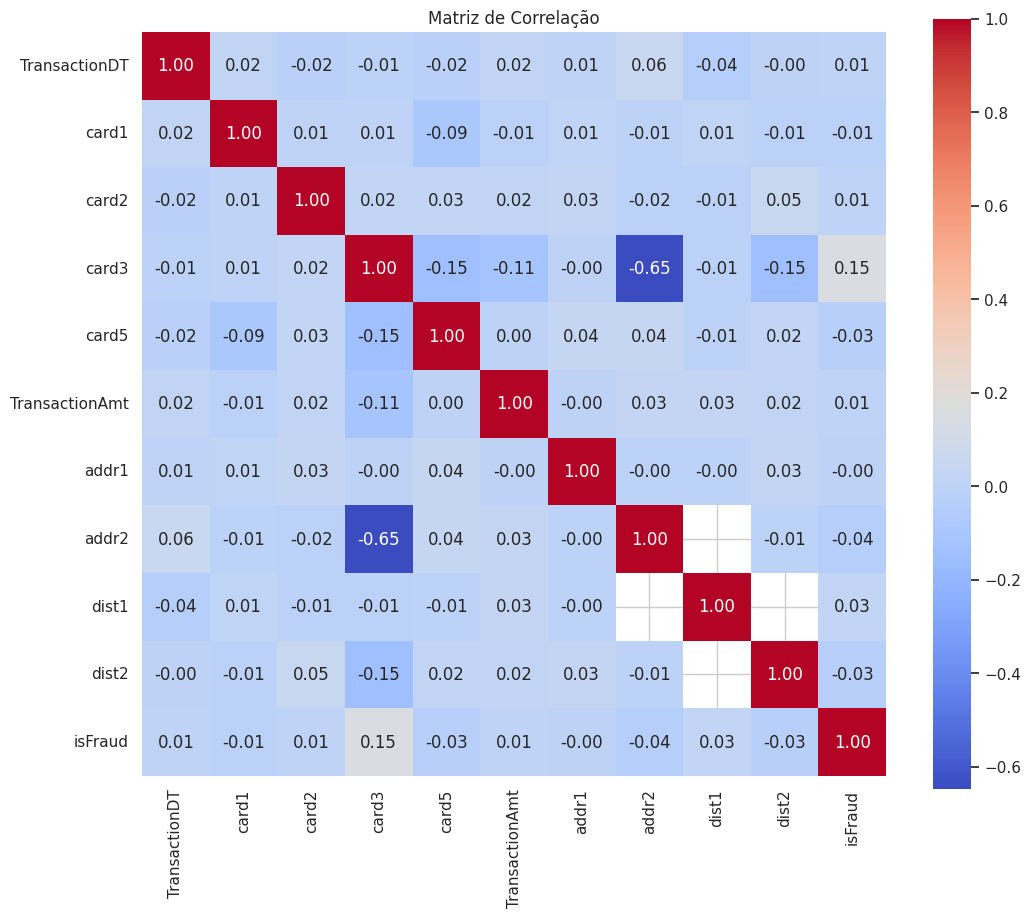

In [89]:
# Calculando a matriz de correlação
correlation_matrix = df_corr[['TransactionDT','card1','card2','card3','card5','TransactionAmt','addr1','addr2','dist1','dist2','isFraud']].corr()

# Exibindo a matriz de correlação
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Matriz de Correlação')
plt.show()

Text(0, 0.5, 'Frequência')

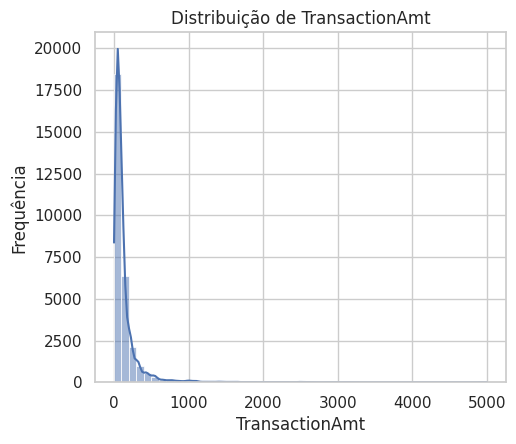

In [90]:
# Configuração do estilo dos gráficos
sns.set(style="whitegrid")
plt.figure(figsize=(18, 10))

# 1. Histograma da distribuição de TransactionAmt
plt.subplot(2, 3, 1)
sns.histplot(df['TransactionAmt'], bins=50, kde=True)
plt.title('Distribuição de TransactionAmt')
plt.xlabel('TransactionAmt')
plt.ylabel('Frequência')

Text(0, 0.5, 'TransactionAmt')

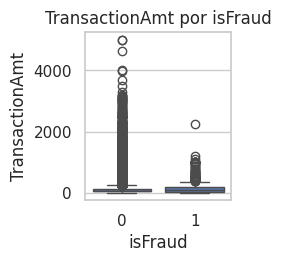

In [91]:
# 2. Boxplot de TransactionAmt segmentado por isFraud
plt.subplot(2, 3, 2)
sns.boxplot(x='isFraud', y='TransactionAmt', data=df)
plt.title('TransactionAmt por isFraud')
plt.xlabel('isFraud')
plt.ylabel('TransactionAmt')

Text(0, 0.5, 'Frequência')

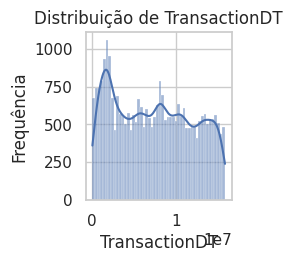

In [92]:
# 5. Histograma para TransactionDT
plt.subplot(2, 3, 5)
sns.histplot(df['TransactionDT'], bins=50, kde=True)
plt.title('Distribuição de TransactionDT')
plt.xlabel('TransactionDT')
plt.ylabel('Frequência')

In [93]:
df['M6'].unique()

array(['T', 'F', nan, 0.0, 1.0, 2.0], dtype=object)

In [94]:
df.describe()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
count,2.952700e+04,29527.000000,2.952700e+04,29527.000000,29527.000000,29527.000000,29097.000000,29458.000000,29527.000000,29310.000000,...,4121.000000,4121.000000,4121.000000,4121.000000,4121.000000,4121.000000,4121.000000,4121.000000,4121.000000,4121.000000
mean,3.281951e+06,0.035865,7.364201e+06,134.555271,3.212687,9879.085142,362.160738,153.276767,2.617909,199.050665,...,0.892017,911.019534,1738.753822,1285.019777,11.001335,68.909609,33.746542,86.413007,204.415190,140.021839
std,1.701660e+05,0.185958,4.606334e+06,230.546640,1.431049,4926.753231,157.913168,11.510956,0.586177,41.576132,...,5.198323,7151.306041,12708.983281,9120.890832,202.211416,372.655976,248.377404,1699.204217,1953.284481,1772.300772
min,2.987002e+06,0.000000,8.646900e+04,0.350000,0.000000,1008.000000,100.000000,100.000000,0.000000,100.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.136142e+06,0.000000,3.082136e+06,43.950000,3.000000,6019.000000,211.000000,150.000000,2.000000,166.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.281553e+06,0.000000,7.264391e+06,68.211000,4.000000,9689.000000,361.000000,150.000000,3.000000,226.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,3.428676e+06,0.000000,1.121817e+07,125.000000,4.000000,14259.000000,512.000000,150.000000,3.000000,226.000000,...,0.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,3.577466e+06,1.000000,1.580980e+07,5001.820000,4.000000,18390.000000,600.000000,231.000000,4.000000,237.000000,...,54.000000,104060.000000,145912.000000,104060.000000,12307.500000,12307.500000,12307.500000,104060.000000,104060.000000,104060.000000


##Mais tratamentos dos dados

In [95]:
df = df.fillna(0)
df = df.drop(['M6', 'M1', 'M2', 'M3', 'M4', 'M5', 'M7', 'M8', 'M9'], axis=1)

In [96]:
X = df.drop(['TransactionID', 'isFraud'], axis=1)
y = df['isFraud']

In [97]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train = np.array(X_train)
y_train = np.array(y_train)
X_test = np.array(X_test)
y_test = np.array(y_test)

X_train_reshape = X_train.reshape((X_train.shape[0], 1, X_train.shape[1])).astype('float32')
X_test_reshape = X_test.reshape((X_test.shape[0], 1, X_test.shape[1])).astype('float32')

In [98]:
# Definindo o modelo LSTM
model = Sequential()
model.add(LSTM(64, input_shape=(X_train_reshape.shape[1], X_train_reshape.shape[2]), return_sequences=True))
model.add(Dropout(0.3))
model.add(LSTM(64))
model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Treinando o modelo com Early Stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
history = model.fit(X_train_reshape, y_train, epochs=20, batch_size=64, validation_data=(X_test_reshape, y_test), callbacks=[early_stopping])

# Previsões no conjunto de teste
y_pred_prob = model.predict(X_test_reshape)
y_pred = (y_pred_prob > 0.5).astype("int32")

# Cálculo das métricas
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_prob)

print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-Score: {f1:.4f}')
print(f'AUC-ROC: {auc:.4f}')


Epoch 1/20


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


370/370 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9586 - loss: 0.2654 - val_accuracy: 0.9644 - val_loss: 0.1539
Epoch 2/20
370/370 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9647 - loss: 0.1583 - val_accuracy: 0.9644 - val_loss: 0.1535
Epoch 3/20
370/370 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9650 - loss: 0.1558 - val_accuracy: 0.9644 - val_loss: 0.1534
Epoch 4/20
370/370 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9634 - loss: 0.1596 - val_accuracy: 0.9644 - val_loss: 0.1534
Epoch 5/20
370/370 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9646 - loss: 0.1563 - val_accuracy: 0.9644 - val_loss: 0.1533
Epoch 6/20
370/370 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9621 - loss: 0.1642 - val_accuracy: 0.9644 - val_loss: 0.1542
Epoch 7/20
370/370 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9640 - loss: 0.1568 - val_accuracy: 0.9644 - val_loss: 0.1534
Epoch 8/20
370/370 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9647 - loss: 0.1548 - val_accuracy: 0.9644 - 

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


#Curva de aprendizado

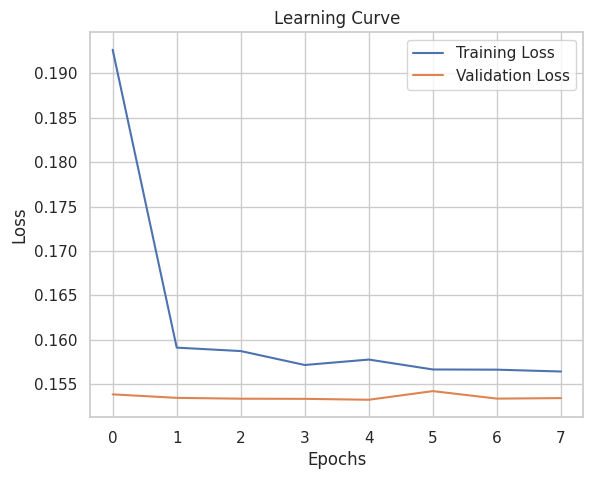

In [99]:
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Learning Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

#Gráfico de acuracia

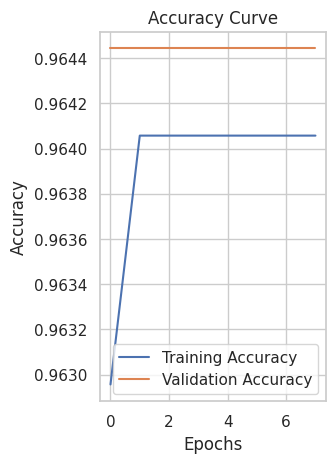

In [100]:
# Gráfico de acurácia
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

#Matriz de confusão

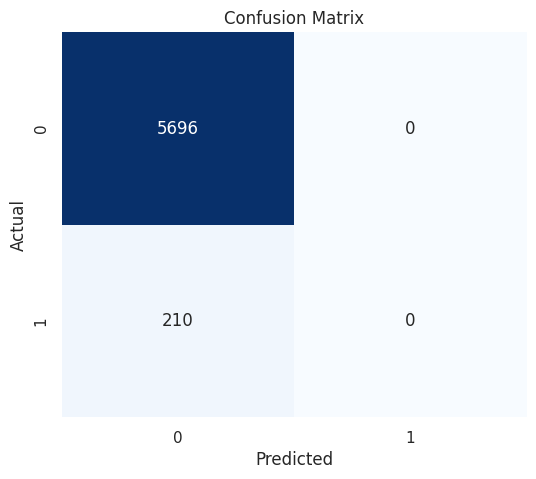

In [101]:
# Matriz de Confusão
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
plt.title('Confusion Matrix')
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#ROC Cure

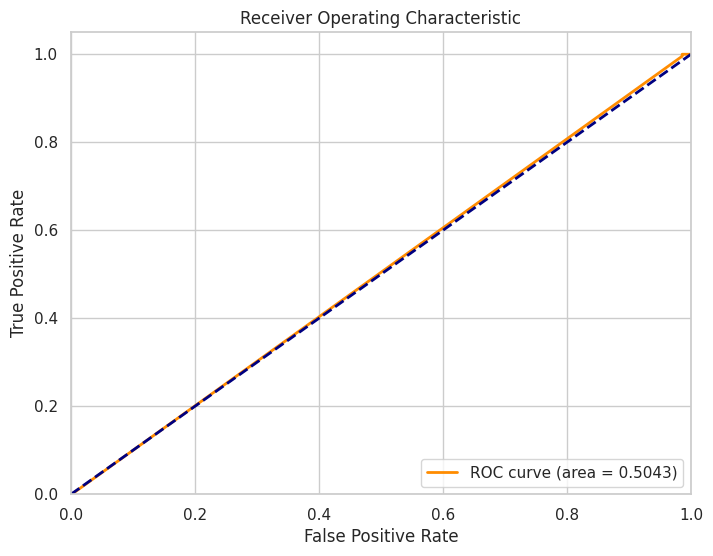

In [102]:
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

#Resultado

O modelo LSTM, embora eficaz para dados sequenciais, pode não ser indicado para a detecção de fraudes neste caso devido à falta de uma dependência temporal forte nas transações e ao desbalanceamento de classes, que resulta em métricas ruins. Alternativas como Random Forest, GBM, regressão logística, redes neurais densas ou técnicas de detecção de anomalias, que lidam melhor com dados tabulares e desbalanceados, são mais apropriadas para capturar fraudes de forma eficaz.






